# Tarea Análisis Exploratorio de Datos

**Autor:** Gil Brandon Garcia Contreras
**Fecha:** 16 de febrero de 2026

## Objetivo

Esta tarea busca que experimenten directamente con el proceso de análisis exploratorio de datos (EDA). A diferencia de otros temas del curso donde aprenderán algoritmos específicos con pasos definidos, el EDA es fundamentalmente una actividad artesanal y creativa. No existe una receta única: cada dataset cuenta una historia diferente, y su trabajo es descubrir cuál es esa historia mediante preguntas inteligentes y visualizaciones apropiadas.

In [61]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno  # pip install missingno

# Cargar datos
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')


ModuleNotFoundError: No module named 'missingno'

In [67]:
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1 # Creación de variable de tamaño de familia
titanic.head() # Primeras filas

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [68]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


In [69]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), str(5)
memory usage: 90.6 KB


## Parte 1: Variación (¿Cómo varían mis datos?)

Variables a analizar:

- Survived: ¿Cuanto porcentaje de gente sobrevivio?
- Pclass: ¿Cuanta gente habia de cada clase?
- Fare: ¿Como se distribuyen la tarifa?
- Age: ¿Como se disribuye la edad?
- FamilySize: ¿Cuanta gente viajaba en familia?

In [89]:
survived = titanic['Survived'].value_counts()
print(survived, survived / len(titanic) * 100)

Survived
0    549
1    342
Name: count, dtype: int64 Survived
0    61.616162
1    38.383838
Name: count, dtype: float64


In [90]:
pcclass = titanic['Pclass'].value_counts()
print(pcclass, pcclass / len(titanic) * 100)

Pclass
3    491
1    216
2    184
Name: count, dtype: int64 Pclass
3    55.106622
1    24.242424
2    20.650954
Name: count, dtype: float64


<Axes: ylabel='Fare'>

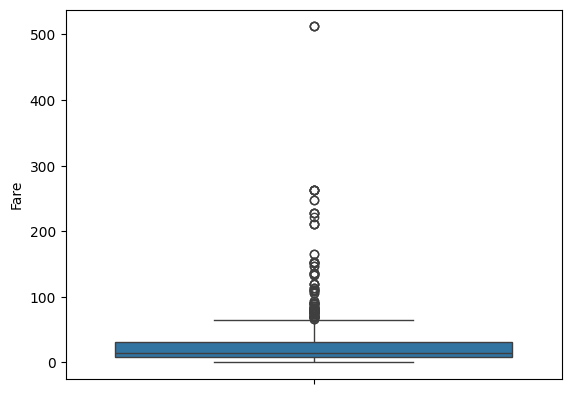

In [78]:
sns.boxplot(data=titanic, y='Fare')

In [82]:
mayores_300 = titanic.query('Fare > 300')

print(mayores_300)

     PassengerId  Survived  Pclass                                Name  \
258          259         1       1                    Ward, Miss. Anna   
679          680         1       1  Cardeza, Mr. Thomas Drake Martinez   
737          738         1       1              Lesurer, Mr. Gustave J   

        Sex   Age  SibSp  Parch    Ticket      Fare        Cabin Embarked  \
258  female  35.0      0      0  PC 17755  512.3292          NaN        C   
679    male  36.0      0      1  PC 17755  512.3292  B51 B53 B55        C   
737    male  35.0      0      0  PC 17755  512.3292         B101        C   

     FamilySize  
258           1  
679           2  
737           1  


<Axes: ylabel='Age'>

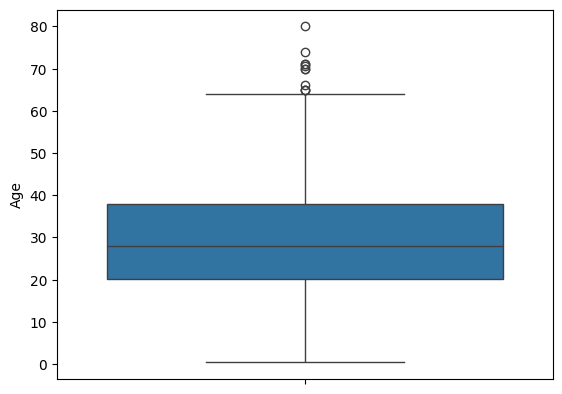

In [79]:
sns.boxplot(data=titanic, y='Age')

In [124]:
mayores_60 = titanic.query('Age >= 60')
menores_5 = titanic.query('Age <= 10')

print(len(mayores_60))
print(mayores_60['Survived'].value_counts())
print(len(menores_5))
print(menores_5['Survived'].value_counts())

26
Survived
0    19
1     7
Name: count, dtype: int64
64
Survived
1    38
0    26
Name: count, dtype: int64


<Axes: ylabel='FamilySize'>

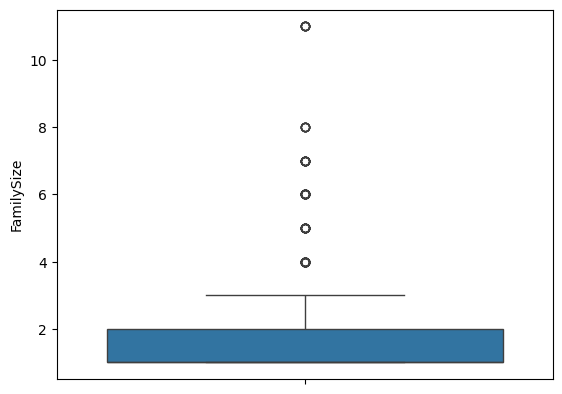

In [92]:
sns.boxplot(data=titanic, y='FamilySize')

In [126]:
family = titanic['FamilySize'].value_counts()

family_11 = titanic.query('FamilySize >= 11')

print(family, family / len(titanic) * 100, family_11)

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64 FamilySize
1     60.269360
2     18.069585
3     11.447811
4      3.254770
6      2.469136
5      1.683502
7      1.346801
11     0.785634
8      0.673401
Name: count, dtype: float64      PassengerId  Survived  Pclass                               Name     Sex  \
159          160         0       3         Sage, Master. Thomas Henry    male   
180          181         0       3       Sage, Miss. Constance Gladys  female   
201          202         0       3                Sage, Mr. Frederick    male   
324          325         0       3           Sage, Mr. George John Jr    male   
792          793         0       3            Sage, Miss. Stella Anna  female   
846          847         0       3           Sage, Mr. Douglas Bullen    male   
863          864         0       3  Sage, Miss. Dorothy Edith "Dolly"  female   

     Age  SibSp  Parch    Ticket   Fare C

Tras analizar las 5 variables que me parecian más interesantes encontre varios detalles interesantes. El porcentaje de sobreviviencia fue del 38%, el cual me parece alto para la tragedia que fue en su momento. Uno pensaria que la supervivencia estaria por los suelos, aunque comparandola con los numeros actuales de supervivencia a catastofres claramente se puede ver la diferencia de tecnologia entre ambas epocas. Por otra parte, analizando las clases de pasajeros me parecio curiosos que la suma procentual de la segunda y primera clase fuera menor que la enteridad de la tercera. Tambien me sorprendio el hecho de que hubiera más participantes de primera clase que de segunda, algo que denota el fenomeno social que fue el barco en su momento. En el apartado de tarifa de boletos se puede notar que existe un punto bastante alejado del resto, lo cual me llamo mucho la atención, revisando por todas las personas que pagaron más de 300 dolares podemos ver que unicamente se encuentran 3. Haciendo una investigación más profunda podemos ver que el pasajero principal fue homas Drake Martínez Cardeza, el cual llevaba a su madre y un sirviente personal. El era el unico que utilizo una de las dos suites principales dentro del Titanic y la razon principal por la que la media de la tarifa es tan alta, cabe aclarar que todos sobrevivieron. Siguiendo con la edad, podemos ver que la mayoria de los pasajeros estaban en un rango de entre 20 y 40 años. Ademas se nota que la mayoria de los mayores de edad no sobrevivieron, mientras que más del 50% de los menores de edad sí. Finalmente, la ultima variable que analize fue el tamaño de las familias, la cual fue una variable creada por el usuario, en esta se pudo ver como la mayoria de personas viajaban sin familiares. Sin embargo, existe una familia con 11 miembros de tercera clase, los Sage, de los cuales ninguno sobrevivio y se desconocen sus edades. 

## Parte 2: Covariación (¿Cómo se relacionan las variables?)

Exploren la covariación entre pares de variables. Ejemplos de preguntas (formulen las suyas):

¿La tasa de supervivencia fue diferente entre clases sociales?
¿Hubo diferencias de supervivencia por género? ¿Y si consideramos clase Y género simultáneamente?
¿Los pasajeros más jóvenes tenían más probabilidad de sobrevivir?
¿El tamaño de la familia (SibSp + Parch) afectó la supervivenci



In [ ]:
g = sns.FacetGrid(titanic, col='Pclass', hue='Survived')
g.map(plt.hist, 'Age', bins=20)
g.add_legend()

In [ ]:
clase = titanic.groupby('Pclass').agg({
    'Survived': 'mean',
    'Fare': ['mean', 'median', 'max']
})

print(clase)

## Parte 3: Valores Faltantes

In [62]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
msno.matrix(titanic)

## Parte 4: Una Pregunta Propia

Esta es la parte más importante. Formulen una pregunta original sobre el dataset que les parezca interesante y que no hayan visto en ejemplos de internet o tutoriales. Algunos criterios:

La pregunta debe requerir relacionar al menos 2 variables
Debe ser respondible con los datos disponibles
Debe requerir cierto razonamiento, no solo hacer una gráfica
Ejemplos de buenas preguntas:

"¿Los pasajeros que viajaban solos tuvieron diferente tasa de supervivencia que los que viajaban en familia?"
"¿Hubo un efecto de 'mujeres y niños primero' que variara según la clase social?"
No se vale: Hacer la misma pregunta que aparece en la documentación de Seaborn o en el primer tutorial de Google.